In [ ]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random
import os

d:\AI Agents Course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Our favorite first step! Crew was doing this for us, by the way.
load_dotenv(override=True)

True

In [54]:

class State(BaseModel):
        
    messages: Annotated[list, add_messages]

In [55]:
graph_builder = StateGraph(State)

In [56]:
NVIDIA_NIM_API_KEY = os.environ['NVIDIA_NIM_API_KEY']
llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning",
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=NVIDIA_NIM_API_KEY
)

def chatbot_node(old_state: State) -> State:
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state

graph_builder.add_node("chatbot", chatbot_node)

In [57]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [58]:
graph = graph_builder.compile()

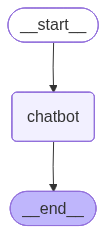

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result['messages'][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='44a5ef45-e3ab-46f1-b709-90b0b9254847'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 17, 'total_tokens': 49, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning', 'system_fingerprint': None, 'id': 'chatcmpl-8a4b45afad7226d9', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e5a41-b580-7ff0-9ad6-9fe07dde0c6e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 32, 'total_tokens': 49, 'input_token_details': {}, 'output_token_details': {}})]}
{'messages': [HumanMessage(content='what is your name', additional_kwargs={}, response_metadata={}, id='93da9d2b-e225-4bcf-bd4f-d646ed7b6170'), AIMessage(content='I’m Nemotron, an AI as

In [39]:
# here we will know how to convert functions into tools
from langchain_community.utilities import GoogleSerperAPIWrapper
import requests
serper = GoogleSerperAPIWrapper()
from langchain_core.tools import Tool
import os
tool_search = Tool(name="search tool", func = serper.run, description="useful when you need more info from an online search")

# now lets write the tool ourselves 

pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})


push_tool = Tool(name="push tool", func = push, description = "useful when you want to send a push notification")

In [40]:
tools = [push_tool, tool_search]

In [45]:
from typing import TypedDict


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [46]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)

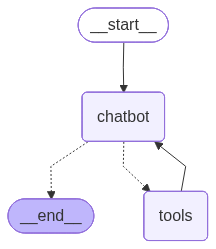

In [47]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


NVIDIA_NIM_API_KEY = os.environ['NVIDIA_NIM_API_KEY']
llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning",
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=NVIDIA_NIM_API_KEY
)

llm_with_tools = llm.bind_tools(tools)

# def chatbot_node(state: State) -> State:
#     response = llm_with_tools.invoke(state["messages"])
#     new_state = State(messages=[response])
#     return new_state

def chatbot_node(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
graph_builder.add_node("chatbot", chatbot_node)
graph_builder.add_node("tools", ToolNode(tools=tools))


graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hr', additional_kwargs={}, response_metadata={}, id='d5156f1d-a572-4ce7-ac7b-fded70473580')]}


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='hr', additional_kwargs={}, response_metadata={}, id='d5156f1d-a572-4ce7-ac7b-fded70473580'), HumanMessage(content='ddd', additional_kwargs={}, response_metadata={}, id='ca850328-4d89-4865-a91e-a0f081cadbbe')]}


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='hr', additional_kwargs={}, response_metadata={}, id='d5156f1d-a572-4ce7-ac7b-fded70473580'), HumanMessage(content='ddd', additional_kwargs={}, response_metadata={}, id='ca850328-4d89-4865-a91e-a0f081cadbbe'), AIMessage(content="It seems like your messages might be incomplete or unclear. Could you please clarify what you need help with? For example:\n- Are you looking for information (I can search for it)?\n- Do you want to send a push notification?\n- Or is there another task you'd like assistance with? \n\nLet me know so I can assist!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 218, 'prompt_tokens': 370, 'total_tokens': 588, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning', 'system_fingerprint': None, 'id': 'chatcmpl-b304e18256f89621', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='hr', additional_kwargs={}, response_metadata={}, id='d5156f1d-a572-4ce7-ac7b-fded70473580'), HumanMessage(content='ddd', additional_kwargs={}, response_metadata={}, id='ca850328-4d89-4865-a91e-a0f081cadbbe'), AIMessage(content="It seems like your messages might be incomplete or unclear. Could you please clarify what you need help with? For example:\n- Are you looking for information (I can search for it)?\n- Do you want to send a push notification?\n- Or is there another task you'd like assistance with? \n\nLet me know so I can assist!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 218, 'prompt_tokens': 370, 'total_tokens': 588, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning', 'system_fingerprint': None, 'id': 'chatcmpl-b304e18256f89621', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
